In [271]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Lab 2: Multiple Encoding Channels

In this lab, you will develop an appreciation for the myriad ways in which the same data can be represented in figures. This is a group lab and you should discuss possible figures with your groupmembers, though you're not obligated to create the same figures. You may use whatever plotting packages you want.

### Part 1: Graph Types

For the two following datasets represent the given association using three different types of figure. **You may not use the same type of figure for any of the six total figures**.

Plotting package documentation is often filled with [inspiration](https://seaborn.pydata.org/examples/index.html).

#### Health costs by age and smoker status

Represent the association between age (x1), smoker status (x2), and health costs (y).

In [272]:
health_costs = pd.read_csv("./data/medical-charges.csv")
health_costs.head()

,age,sex,smoker,charges
0,19,female,yes,16884.92400
1,18,male,no,1725.55230
2,28,male,no,4449.46200
3,33,male,no,21984.47061
4,32,male,no,3866.85520


Text(0.5, 1.0, 'Association between age and health costs')

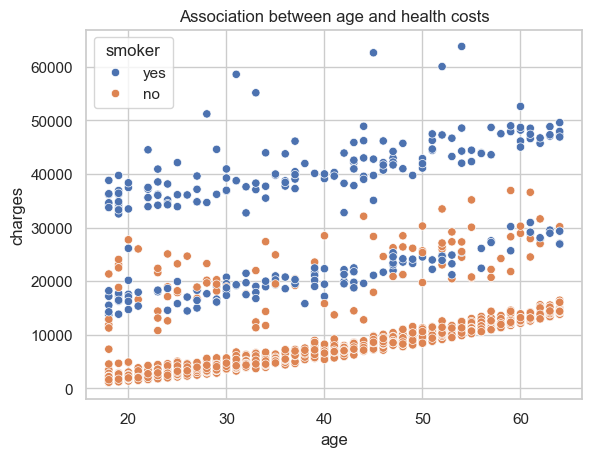

In [273]:
### Figure 1
fig, ax = plt.subplots()

sns.scatterplot(data = health_costs, x = 'age', y = 'charges', hue = 'smoker')


ax.set_title('Association between age and health costs')

Text(0.5, 1.0, 'Association between age and health costs')

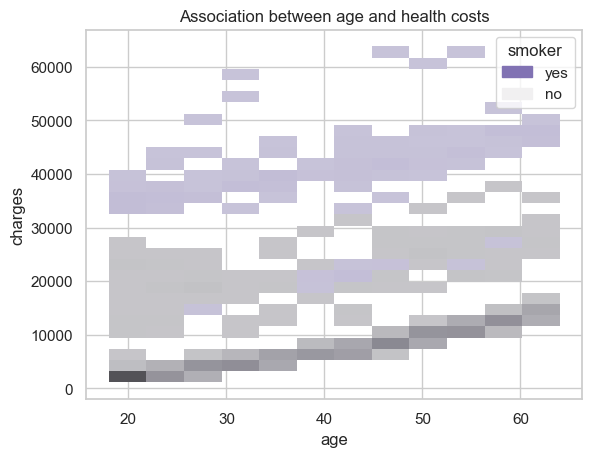

In [274]:
### Figure 2

fig, ax = plt.subplots()

sns.histplot(data = health_costs, x = 'age', y = 'charges',
             hue = 'smoker', palette = 'light:m_r')

ax.set_title('Association between age and health costs')

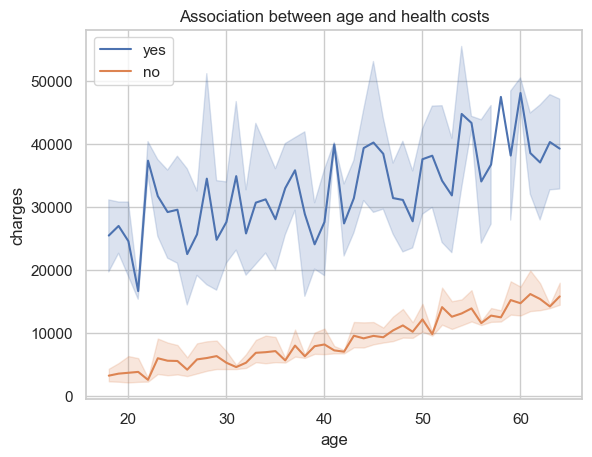

In [275]:
### Figure 3

fig, ax = plt.subplots()

sns.lineplot(data = health_costs, x = 'age', y = 'charges', hue = 'smoker')

ax.set_title('Association between age and health costs')
ax.legend(loc = 'best')

Now explain what **each figure emphasizes** relative to the others. Do they complement one another or is one much better than the others?

**Your response: The only figure that represents the data well is the lineplot, since the other ones don't compliment each other very well.

#### Student performance by sleep hours

Represent the association between good or bad sleep, and student performance index. Good sleep is >= 7 hours and bad sleep is < 7 hours.

In [276]:
students = pd.read_csv("./data/StudentPerformance.csv")
students

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [277]:
### Figure 1
# students['Sleep Quality'] = students[students['Sleep Hours'] >= 7 | students[students['Sleep Hours'] < 7]: 'bad']

students['Sleep Quality'] = np.where(students['Sleep Hours'] >=7 , 'Good', 'Bad')
students

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Sleep Quality
0,7,99,Yes,9,1,91.0,Good
1,4,82,No,4,2,65.0,Bad
2,8,51,Yes,7,2,45.0,Good
3,5,52,Yes,5,2,36.0,Bad
4,7,75,No,8,5,66.0,Good
...,...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0,Bad
9996,7,64,Yes,8,5,58.0,Good
9997,6,83,Yes,8,5,74.0,Good
9998,9,97,Yes,7,0,95.0,Good


<Axes: xlabel='Sleep Quality', ylabel='Performance Index'>

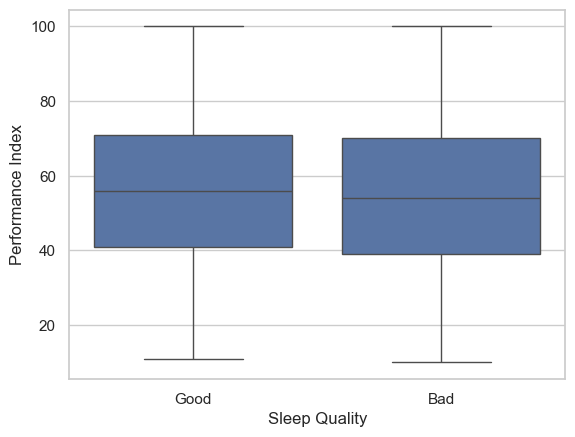

In [278]:
sns.boxplot(data = students, x = 'Sleep Quality', y = 'Performance Index')

<Axes: xlabel='Performance Index', ylabel='Sleep Quality'>

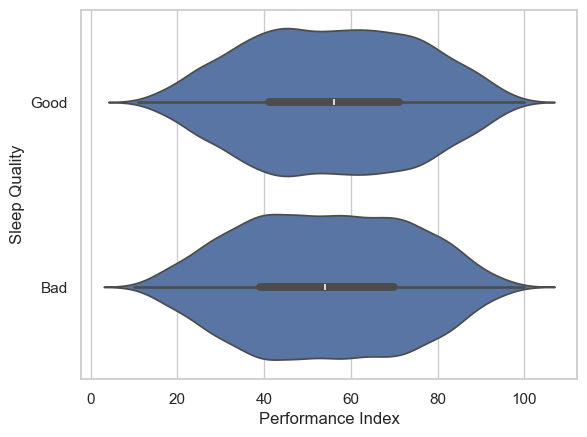

In [279]:
### Figure 2
sns.violinplot(data = students, x = 'Performance Index', y = 'Sleep Quality')

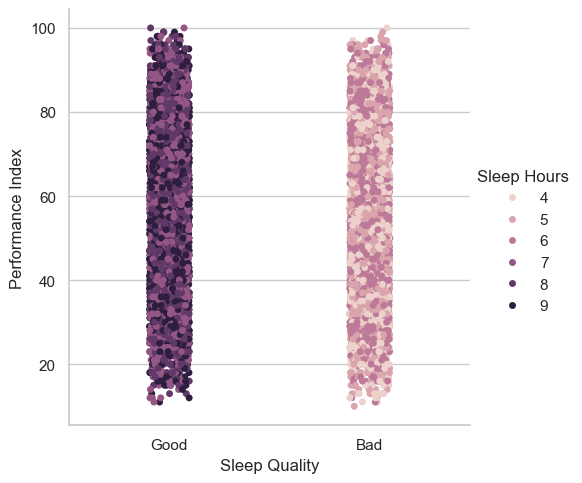

In [280]:
### Figure 3

sns.catplot(data = students, x = 'Sleep Quality', y = 'Performance Index', hue = 'Sleep Hours')

Now explain what **each figure emphasizes** relative to the others. Do they complement one another or is one much better than the others?

**Your response: Box plot represents the data best, and it is easier to see the median difference.**

### Part 2: Color

In this part, you will plot the same figure (mean monthly temperature in Oregon; provided) 5 times but using color differently in each iteration. Specifically, you must address each of the following prompts with color, one per figure. You may edit other visual aesthetics of the figure as well, but you must change color in each figure.

Color API [reference](https://seaborn.pydata.org/tutorial/color_palettes.html).

**Using color**:

1. Smoothly emphasize the differences beween higher and lower temperatures.
2. Emphasize summer and winter months
3. Emphasize observations from different years
4. Emphasize the hottest and coldest months in the time series
5. Make the figure attractive but use color that has no semantic meaning (i.e. no connection to the data)

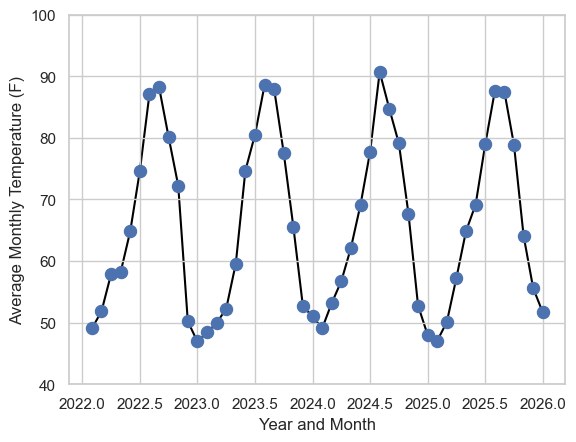

In [281]:
temps = pd.read_csv("./data/eugene_monthly_temps.csv")
temps['Month'] = pd.to_datetime(temps['Month'], format = '%b').dt.month
temps['Year_month'] = temps["Year"] + temps["Month"]/12
temps_recent = temps[temps["Year"].isin([2022,2023,2024,2025])]

sns.lineplot(data = temps_recent, x = "Year_month", y = "meanT_F", c = "black", zorder = 0)
plt.scatter(temps_recent["Year_month"], temps_recent["meanT_F"], s = 75)
plt.ylim(40,100)
plt.ylabel("Average Monthly Temperature (F)")
plt.xlabel("Year and Month");

In [282]:
sns.color_palette("coolwarm", as_cmap=True)

cmap = sns.color_palette("coolwarm", as_cmap=True)

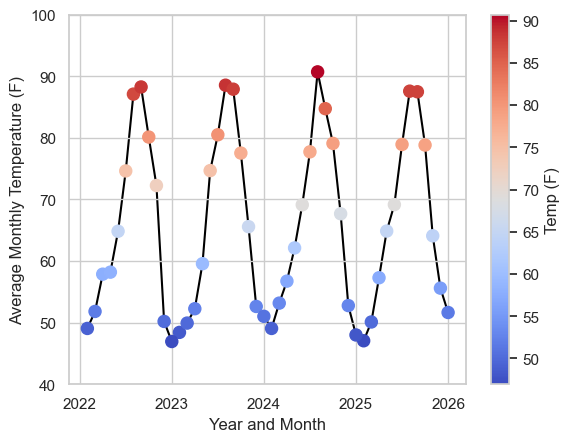

In [283]:
### Prompt 1: Smoothly emphasize the differences beween higher and lower temperatures.

sns.lineplot(data = temps_recent, x = "Year_month", y = "meanT_F", c = "black", zorder = 0)

plt.scatter(temps_recent["Year_month"], temps_recent["meanT_F"], s = 75,
            c = temps_recent['meanT_F'],
           cmap = cmap)


plt.ylim(40,100)
plt.ylabel("Average Monthly Temperature (F)")
plt.xlabel("Year and Month");
plt.colorbar(label="Temp (F)")

In [284]:
### Prompt 2: Emphasize summer and winter months

# students['Sleep Quality'] = np.where(students['Sleep Hours'] >=7 , 'Good', 'Bad')

summer = [6, 7, 8]
winter = [12, 1, 2]

temps_recent['Season'] = np.where(temps_recent['Month'].isin(summer), 'summer',
                                  np.where(temps_recent['Month'].isin(winter), 'winter', 'other')
                                 )

# temps_recent.head()
# made a new column to specify which months are considered summer, winter, and other 

/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_2354/2484681287.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temps_recent['Season'] = np.where(temps_recent['Month'].isin(summer), 'summer',


In [285]:
sns.color_palette("Spectral", as_cmap=True)

cmap = sns.color_palette("Spectral", as_cmap=True)

/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_2354/872748419.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temps_recent['Season Colors'] = temps_recent['Season'].map(seasons)


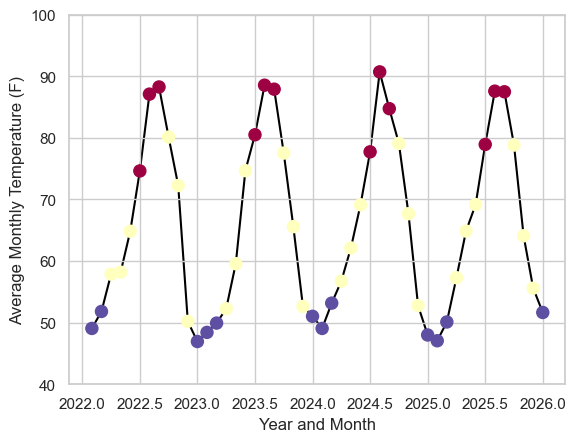

In [286]:
sns.lineplot(data = temps_recent, x = "Year_month", y = "meanT_F", c = "black", zorder = 0)


# plt.scatter(..., c = ...) won't work like the plot prior due to our season column not being ints or colors
# so we will apply an int to each one
seasons = {'winter': 2, 'other': 1, 'summer': 0}
temps_recent['Season Colors'] = temps_recent['Season'].map(seasons)

plt.scatter(temps_recent["Year_month"], temps_recent["meanT_F"], s = 75,
           c = temps_recent['Season Colors'],
           cmap = cmap)


plt.ylim(40,100)
plt.ylabel("Average Monthly Temperature (F)")
plt.xlabel("Year and Month");

In [287]:
temps_recent['Year'].unique()

array([2022, 2023, 2024, 2025])

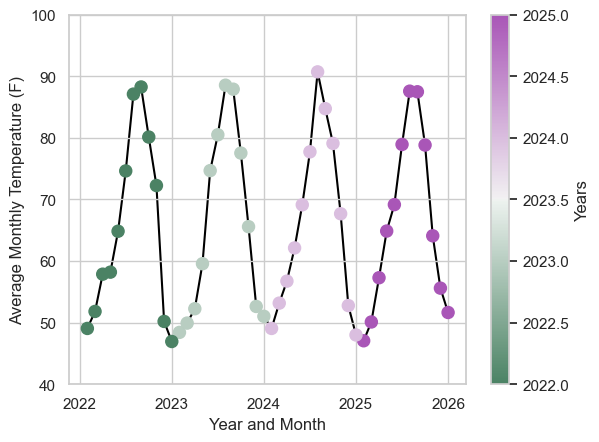

In [288]:
### Prompt 3: Emphasize observations from different years

cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)

sns.lineplot(data = temps_recent, x = "Year_month", y = "meanT_F", c = "black", zorder = 0)

plt.scatter(temps_recent["Year_month"], temps_recent["meanT_F"], s = 75, 
            c = temps_recent['Year'], cmap = cmap)

plt.ylim(40,100)
plt.ylabel("Average Monthly Temperature (F)")
plt.xlabel("Year and Month");
plt.colorbar(label = 'Years')

/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_2354/3639130906.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temps_recent['hot-cold'] = 'other'
/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_2354/3639130906.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temps_recent['hot-cold int'] = temps_recent['hot-cold'].map(temp)


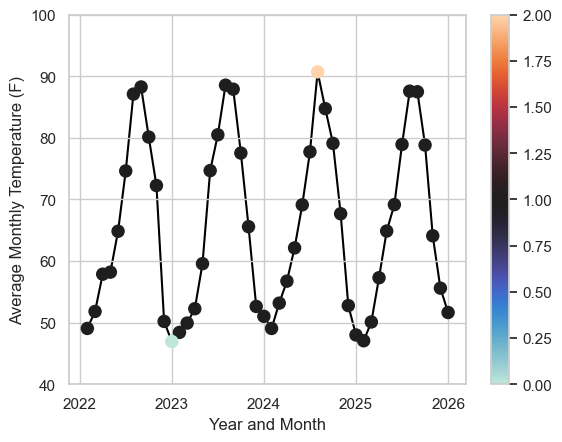

In [304]:
### Prompt 4: Emphasize the hottest and coldest months in the time series

cmap = sns.color_palette("icefire", as_cmap=True)

hottest = temps_recent['meanT_F'].idxmax()
coldest = temps_recent['meanT_F'].idxmin()

# cant do np.where since the conditionals will set to all, but we only want the hottest and coldest months

temps_recent['hot-cold'] = 'other'
temps_recent.loc[hottest, 'hot-cold'] = 'hottest'
temps_recent.loc[coldest, 'hot-cold'] = 'coldest' 
temp = {'coldest': 0, 'other': 1, 'hottest': 2}
temps_recent['hot-cold int'] = temps_recent['hot-cold'].map(temp)


sns.lineplot(data = temps_recent, x = "Year_month", y = "meanT_F", c = "black", zorder = 0)

plt.scatter(temps_recent["Year_month"], temps_recent["meanT_F"], s = 75,
           c = temps_recent['hot-cold int'],
            cmap = cmap)


plt.ylim(40,100)
plt.ylabel("Average Monthly Temperature (F)")
plt.xlabel("Year and Month");
plt.colorbar()

Text(0.5, 1.0, 'Monthly Average Temperatures (2022 - 2025)')

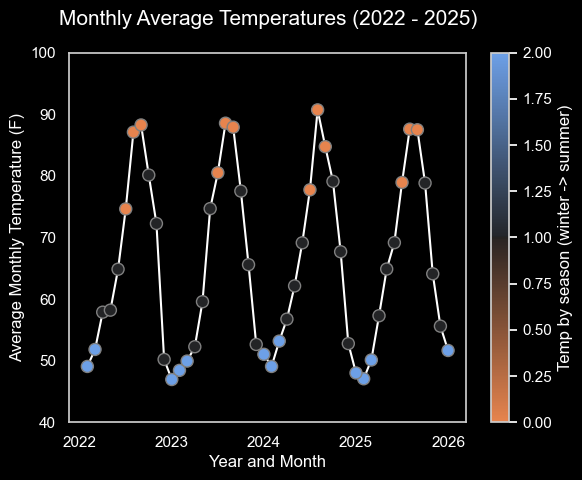

In [359]:
### Prompt 5: Make the figure attractive but use color that has no semantic meaning (i.e. no connection to the data)

cmap = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=True)


plt.figure(facecolor="black")
ax = plt.gca()
ax.set_facecolor("black")
plt.grid(False)

sns.lineplot(data = temps_recent, x = "Year_month", y = "meanT_F", c = "white", zorder = 0)
plt.scatter(temps_recent["Year_month"], temps_recent["meanT_F"], s = 75,
            c = temps_recent['Season Colors'],
            cmap = cmap.reversed(),
            edgecolors = 'grey'
           )

plt.xticks(color = 'white')
plt.yticks(color = 'white')
plt.ylim(40,100)
plt.ylabel("Average Monthly Temperature (F)", color = 'white')
plt.xlabel("Year and Month", color = 'white');

bar = plt.colorbar()
bar.set_label('Temp by season (winter -> summer)', color = 'white')
bar.ax.tick_params(color = 'white', labelcolor = 'white')

plt.title('Monthly Average Temperatures (2022 - 2025)', color = 'white',
          pad = 20, loc = 'center', fontsize = 15
         )

Once done, submit your lab to the relevant assignment on Canvas.